# Kv2.1 MolProbity / clashscore analysis

All six WT/L403A/F412L × vanilla/masked ensembles are compared. The conformational extension
uses the exact structures and existing chain-resolved coordinates from
`Kv21_L403A_conformational_validation.ipynb`. Established tetramer/interface/alignment QC is retained.

## Reproducible setup
Run from the repository root or channel directory. Dependencies: NumPy, pandas, SciPy, statsmodels, Matplotlib, seaborn, and Jupyter. MolProbity tables remain in the local downloaded directory. No upload or move is performed. Shared functions live in `shared/molprobity_analysis.py`, as in the existing analyses.

In [1]:
from pathlib import Path
import sys, os, json, platform, importlib.metadata
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'shared/data_access.py').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from shared import molprobity_analysis as mp
CHANNEL = 'kv21'
OUT = mp.output_dir(CHANNEL)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 24)
mp.apply_kv21_style()


## Data-access boundary
Set `VGIC_MOLPROBITY_ROOT` or `DATA_ROOT` to the downloaded directory. Future Hugging Face migration only needs to replace the loader with explicit paths through the existing `shared.data_access.resolve`; downstream analysis accepts the same DataFrame. Existing structural-QC and conformational inputs already use that resolver, including local/cache/offline behavior.

In [2]:
DATA_ROOT = os.environ.get('VGIC_MOLPROBITY_ROOT', str(ROOT/'molprobity_download'))
raw, inventory, total_csv_files = mp.load_molprobity(CHANNEL, DATA_ROOT)
inventory.to_csv(OUT/'tables/input_inventory.csv', index=False)
print(f'{total_csv_files} CSVs in downloaded directory; {len(inventory)} for this channel; {len(raw):,} rows')
display(inventory)


19 CSVs in downloaded directory; 6 for this channel; 35,994 rows


,csv_file,rows,sha256
0,Kv21_f412l_masked_clashscores/Kv21_f412l_maske...,6000,f26ec1e42b374963daef59f988e9ceb55dc14e24f93f24...
1,Kv21_f412l_vanilla_clashscores/Kv21_f412l_vani...,6000,0cccf5f3a23160e06f848f62464a2cb9eedbc3e4b2bc00...
2,Kv21_l403a_masked_clashscores/Kv21_l403a_maske...,6000,06a6c280df40307f661b6d7365aaa8c8de3fc299c8cb88...
3,Kv21_l403a_vanilla_clashscores/Kv21_l403a_vani...,5994,afd0731e2a5689bd673ff89f263c0a7307866cf9ac949e...
4,Kv21_wt_masked_clashscores/Kv21_wt_masked_clas...,6000,5e1960dc05f80b0e775790edd7452d1f12f7bd8bc16763...
5,Kv21_wt_vanilla_clashscores/Kv21_wt_vanilla_cl...,6000,ac367b725df250ed8924fd7477809d7117b8bad7540e9c...


## Audit before plotting
The expected grid uses each ensemble’s recorded seed labels, AF models 1–5, r0–r10, and final. Missing whole trajectories/seeds are additionally checked against the existing model manifest. Raw input hashes are saved above. NaN recycle is expected only for final/base models; missing rank is allowed and reported.

In [3]:
data, audit = mp.audit_data(raw, CHANNEL, OUT)
display(audit)
display(pd.read_csv(OUT/'tables/missing_snapshots.csv'))
display(pd.read_csv(OUT/'tables/manifest_discrepancies.csv'))
display(pd.read_csv(OUT/'tables/row_anomalies.csv'))
cohorts = mp.select_cohorts(data, CHANNEL, OUT)
summary = pd.concat([mp.describe(frame, name) for name, frame in cohorts.items()], ignore_index=True)
summary.to_csv(OUT/'tables/descriptive_statistics.csv', index=False)
display(summary[(summary.cohort=='all_recorded') & summary.metric.eq('clashscore')].round(3))
display(pd.read_csv(OUT/'tables/selection_audit.csv'))


Audit: 35,994 rows, 0 failed, 0 invalid metric rows; 6 absent expected snapshots; 0 explicitly excluded rows.


,ensemble,rows,ok,ok_fraction,eligible,failed,missing_clashscore,nonfinite_clashscore,duplicate_names,duplicate_keys,missing_grid_snapshots,seeds,seed_min,seed_max,missing_rank,final_r10_pairs,final_r10_identical_metrics,manifest_rows,manifest_missing,manifest_extra
0,F412L | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
1,F412L | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,78,177,0,500,500,6000,0,0
2,L403A | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
3,L403A | vanilla,5994,5994,1.0,5994,0,0,0,0,0,6,100,55,154,5994,499,499,5994,0,0
4,WT | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
5,WT | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,48,147,0,500,500,6000,0,0


,ensemble,seed,af_model,snapshot
0,L403A | vanilla,154,5,final
1,L403A | vanilla,154,5,r10
2,L403A | vanilla,154,5,r6
3,L403A | vanilla,154,5,r7
4,L403A | vanilla,154,5,r8
5,L403A | vanilla,154,5,r9


,ensemble,model_name,issue


,run_name,input_folder,model_name,rank,af_model,seed,recycle,snapshot,clashscore,n_bad_clashes,max_overlap,status,...,source_path,genotype,protocol,ensemble,csv_file,analysis_eligible,malformed_numeric,invalid_identity,duplicate_name,duplicate_key,invalid_metric,failed_status_or_exit


,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
0,all_recorded,F412L | masked,clashscore,6000,100,50.550,45.050,64.775,19.725,59.540,25.080,32.11,339.09
3,all_recorded,F412L | vanilla,clashscore,6000,100,45.810,36.228,55.920,19.693,48.977,16.940,22.60,218.63
6,all_recorded,L403A | masked,clashscore,6000,100,48.910,43.138,62.588,19.450,56.802,23.559,29.41,330.21
9,all_recorded,L403A | vanilla,clashscore,5994,100,45.785,38.585,57.598,19.013,50.238,17.231,22.65,203.36
12,all_recorded,WT | masked,clashscore,6000,100,49.520,43.778,64.985,21.207,58.440,24.626,28.99,288.99
15,all_recorded,WT | vanilla,clashscore,6000,100,44.640,38.400,56.415,18.015,49.229,16.020,24.45,143.01


,ensemble,selection,source,requested,matched,excluded_failed,excluded_by_structural_qc
0,F412L | masked,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_f412l_masked...,3578,3578,0,2422
1,F412L | vanilla,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_f412l_vanill...,4407,4407,0,1593
2,L403A | masked,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,3693,3693,0,2307
3,L403A | vanilla,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,4371,4371,0,1623
4,WT | masked,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,3658,3658,0,2342
5,WT | vanilla,3 Å + structural/interface/alignment QC,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,4562,4562,0,1438


## Statistical design and interpretation

The complete downloaded table is audited before filtering. `status != ok`, nonzero exit codes,
nonfinite/negative diagnostics and malformed identities are reported explicitly. Ambiguous identities
or mismatched manifests stop execution. Empty anomaly CSVs still retain their headers.

Every ensemble has up to 100 seeds × 5 AF models × 11 recycle snapshots plus a final/base file.
The final/base file has identical recorded MolProbity metrics to r10 for every available trajectory;
that is **metric equality, not a coordinate checksum**. To avoid double weighting those observations,
`all_recycles` excludes final copies. `final_only` is a separate sensitivity analysis.

The primary scientific comparison uses the repository's existing QC subset, independently of clashscore:
3 Å convergence for Cav1.2/Nav1.5 and the established structural/interface/alignment-QC distance
selection for Kv2.1. All raw distributions and excluded counts remain visible. QC-selected results
describe survivors, not all generated models. No new clashscore cutoff is used.

For each metric, average snapshots within seed/AF-model trajectory, then average AF models within seed.
This gives each retained seed equal weight and avoids treating recycles or the five AF models as
independent replicates. Point estimates are seed-balanced mean differences B−A; 95% percentile
bootstrap intervals use 3,000 seed draws. When seed-label sets match completely, nominal paired-seed
t tests and the existing `paired_common_seed_bootstrap` are used. Otherwise Welch tests compare all
retained seed summaries. Both independent-seed and common-label paired sensitivities are exported.
Shared numeric labels do **not** establish shared random-number streams; no seeds are renumbered,
and rank is never a pairing key. Common-label sensitivity may change the population when ranges differ.

BH correction covers all planned pairwise comparisons × all three metrics within each channel/cohort;
primary, independent, and common-label p-values form separate families. Supplemental cohort families
are exploratory. The seed rank-biserial effect is P(B>A)−P(B<A) across seed summaries, with ties zero;
it describes marginal ordering even for nominally paired tests. Model medians/IQRs are descriptive
snapshot summaries and are a different estimand from the seed-balanced mean contrast.

AF-model/snapshot-adjusted regressions provide a sensitivity check with standard errors clustered by
recorded seed. Rank is an output ordering variable, is absent for Kv2.1 L403A vanilla, and is inspected
descriptively rather than controlled as if it were a randomized covariate. These uncertainty estimates
describe computational sampling, not biological replication or a validated clinical effect.

Clashscore is a normalized global clash statistic ([Phenix glossary](https://www.phenix-online.org/version_docs/1.8.2-1296/glossary.htm)).
`n_bad_clashes` is an absolute count and `max_overlap` is a single extreme; they are complementary
diagnostics, not interchangeable biological measures. The local export does not record Phenix version,
hydrogen options, the atom denominator, or atom-level clash identities. Absolute validation grades,
cross-channel biological comparisons, and residue-specific attribution require additional provenance.


In [4]:
contrasts = mp.contrast_statistics(cohorts, CHANNEL, OUT)
primary = contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.eq('clashscore')]
display(primary[['A','B','N_A','N_B','n_seeds_A','n_seeds_B','common_seeds',
                 'common_model_snapshots','only_A_snapshots','only_B_snapshots',
                 'paired_seed_correlation','primary_test']])
display(primary[['A','B','median_difference','seed_mean_difference','CI_low','CI_high',
                 'seed_rank_biserial','q_BH','independent_q_BH','common_seed_difference',
                 'common_seed_CI_low','common_seed_CI_high','common_seed_q_BH']].round(4))


,A,B,N_A,N_B,n_seeds_A,n_seeds_B,common_seeds,common_model_snapshots,only_A_snapshots,only_B_snapshots,paired_seed_correlation,primary_test
27,WT | vanilla,WT | masked,4562,3658,100,100,85,3020,1542,638,0.128024,Welch seed t
30,L403A | vanilla,L403A | masked,4371,3693,100,100,78,2760,1611,933,-0.117301,Welch seed t
33,F412L | vanilla,F412L | masked,4407,3578,100,100,55,1860,2547,1718,0.150719,Welch seed t
36,WT | vanilla,L403A | vanilla,4562,4371,100,100,93,3914,648,457,0.079167,Welch seed t
39,WT | vanilla,F412L | vanilla,4562,4407,100,100,70,2935,1627,1472,0.063710,Welch seed t
42,L403A | vanilla,F412L | vanilla,4371,4407,100,100,77,3074,1297,1333,0.110479,Welch seed t
45,WT | masked,L403A | masked,3658,3693,100,100,100,3451,207,242,0.636030,paired nominal seed t
48,WT | masked,F412L | masked,3658,3578,100,100,100,3390,268,188,0.593197,paired nominal seed t
51,L403A | masked,F412L | masked,3693,3578,100,100,100,3312,381,266,0.547652,paired nominal seed t


,A,B,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH,independent_q_BH,common_seed_difference,common_seed_CI_low,common_seed_CI_high,common_seed_q_BH
27,WT | vanilla,WT | masked,3.355,2.0760,1.1055,3.0671,0.3230,0.0001,0.0002,1.9449,0.9946,2.9583,0.0005
30,L403A | vanilla,L403A | masked,2.120,0.9113,-0.0712,1.8420,0.1289,0.0981,0.0981,0.9134,-0.1693,2.0164,0.1659
33,F412L | vanilla,F412L | masked,3.600,3.8214,3.0306,4.6396,0.6530,0.0000,0.0000,3.8137,2.9364,4.6713,0.0000
36,WT | vanilla,L403A | vanilla,0.820,0.2126,-0.7798,1.2127,0.0408,0.7323,0.7323,0.2492,-0.7273,1.2487,0.6790
39,WT | vanilla,F412L | vanilla,1.010,-0.4960,-1.4135,0.3781,-0.0630,0.3404,0.3404,-0.5401,-1.6572,0.5111,0.3777
42,L403A | vanilla,F412L | vanilla,0.190,-0.7086,-1.6356,0.1963,-0.1174,0.2031,0.2031,-0.8765,-1.8266,0.1296,0.1523
45,WT | masked,L403A | masked,-0.415,-0.9521,-1.4909,-0.4277,-0.1742,0.0022,0.0768,-0.9521,-1.4909,-0.4277,0.0022
48,WT | masked,F412L | masked,1.255,1.2494,0.7087,1.7748,0.2572,0.0001,0.0147,1.2494,0.7087,1.7748,0.0001
51,L403A | masked,F412L | masked,1.670,2.2015,1.6412,2.7369,0.4234,0.0000,0.0000,2.2015,1.6412,2.7369,0.0000


## Clashscore distributions and effect sizes
Violins retain every eligible individual snapshot with median and quartiles; no outliers are clipped. The paired raw/QC panels expose selection effects. The contrast figure shows seed-balanced differences and 95% bootstrap intervals; q-values are reported without significance stars. Colors, typography, thin outlines, light grids, and PDF/300-dpi PNG exports follow `shared.plotting` and existing conformational figures.

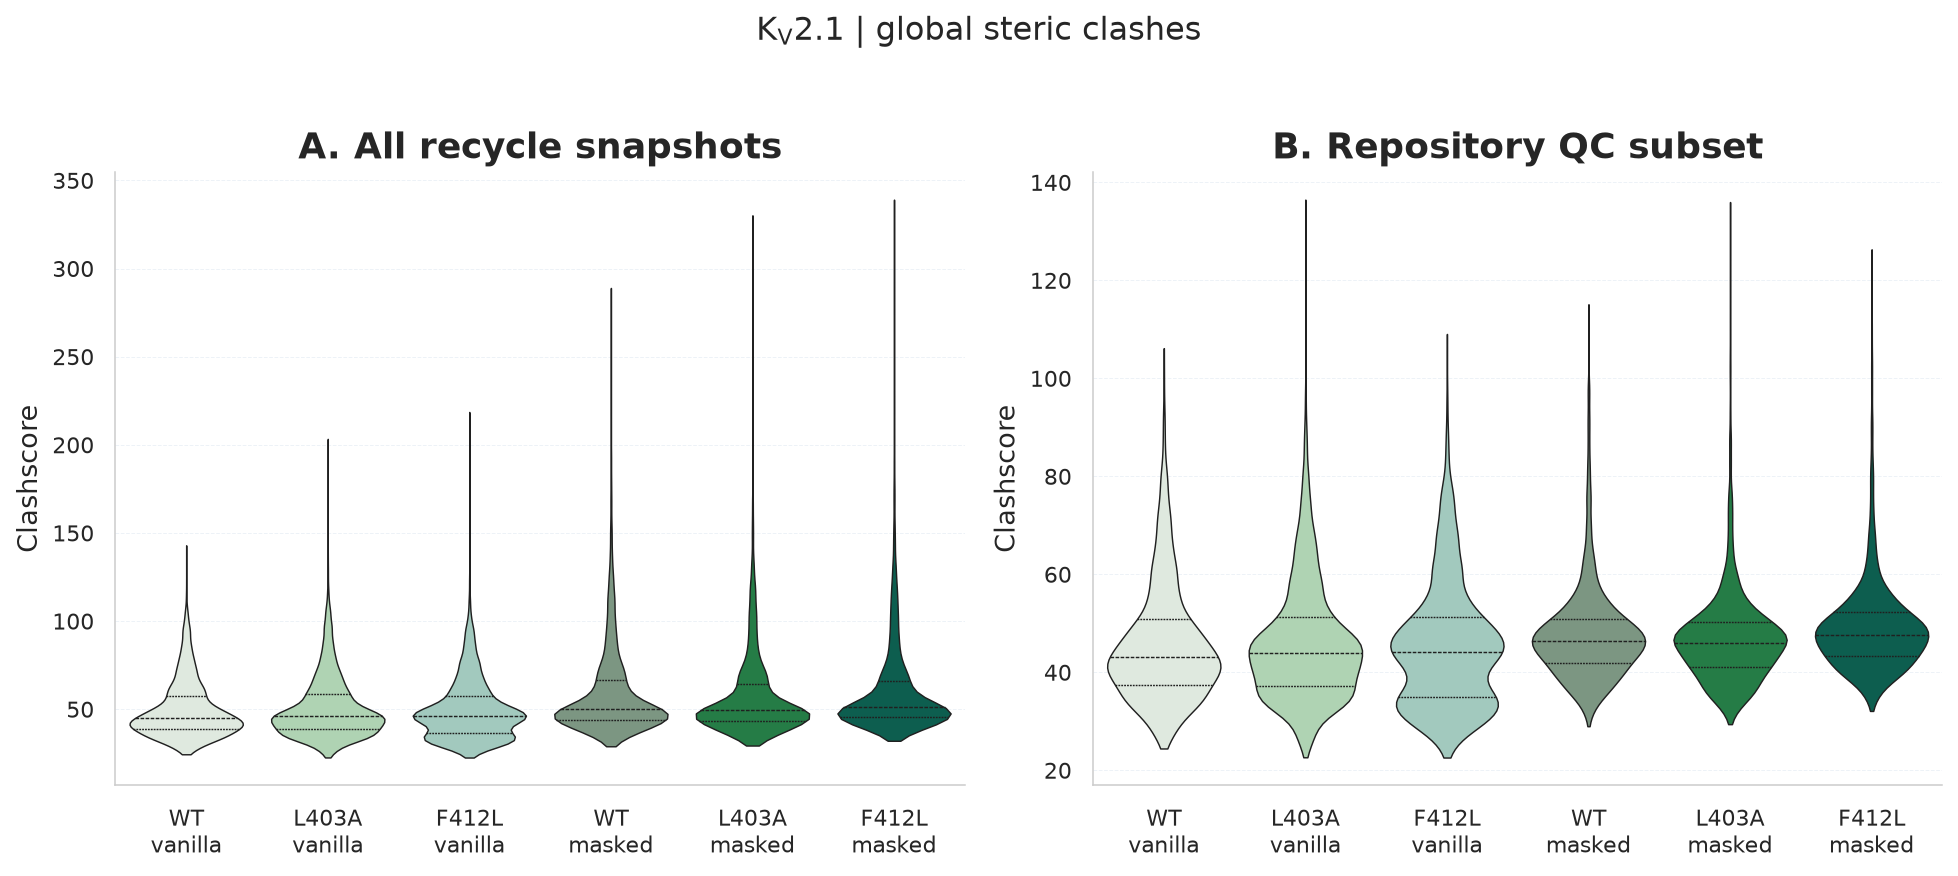

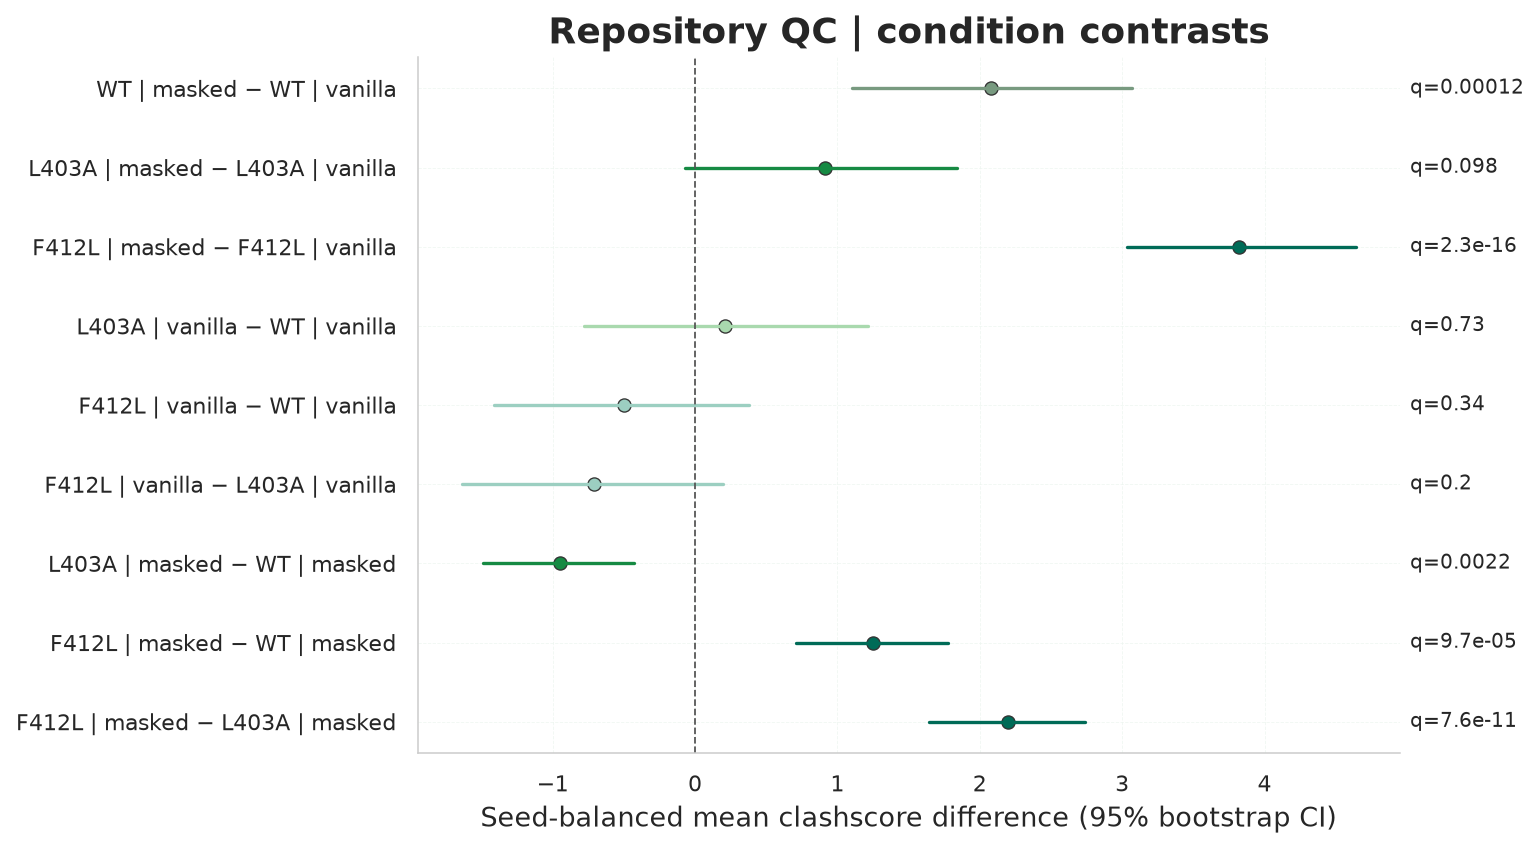

### Results on the repository QC subset

Model medians describe retained snapshots. Differences and confidence intervals below use equal AF-model weights within seed and seed-level inference.
- **WT | masked versus WT | vanilla:** model medians 46.44 versus 43.08 (Δ +3.36); seed-balanced mean Δ +2.08, 95% CI [1.11, 3.07]; seed rank-biserial effect +0.32; BH q=0.000123.
- **L403A | masked versus L403A | vanilla:** model medians 46.02 versus 43.90 (Δ +2.12); seed-balanced mean Δ +0.91, 95% CI [-0.07, 1.84]; seed rank-biserial effect +0.13; BH q=0.0981.
- **F412L | masked versus F412L | vanilla:** model medians 47.69 versus 44.09 (Δ +3.60); seed-balanced mean Δ +3.82, 95% CI [3.03, 4.64]; seed rank-biserial effect +0.65; BH q=2.27e-16.
- **L403A | vanilla versus WT | vanilla:** model medians 43.90 versus 43.08 (Δ +0.82); seed-balanced mean Δ +0.21, 95% CI [-0.78, 1.21]; seed rank-biserial effect +0.04; BH q=0.732.
- **F412L | vanilla versus WT | vanilla:** model medians 44.09 versus 43.08 (Δ +1.01); seed-balanced mean Δ -0.50, 95% CI [-1.41, 0.38]; seed rank-biserial effect -0.06; BH q=0.34.
- **F412L | vanilla versus L403A | vanilla:** model medians 44.09 versus 43.90 (Δ +0.19); seed-balanced mean Δ -0.71, 95% CI [-1.64, 0.20]; seed rank-biserial effect -0.12; BH q=0.203.
- **L403A | masked versus WT | masked:** model medians 46.02 versus 46.44 (Δ -0.41); seed-balanced mean Δ -0.95, 95% CI [-1.49, -0.43]; seed rank-biserial effect -0.17; BH q=0.0022.
- **F412L | masked versus WT | masked:** model medians 47.69 versus 46.44 (Δ +1.25); seed-balanced mean Δ +1.25, 95% CI [0.71, 1.77]; seed rank-biserial effect +0.26; BH q=9.72e-05.
- **F412L | masked versus L403A | masked:** model medians 47.69 versus 46.02 (Δ +1.67); seed-balanced mean Δ +2.20, 95% CI [1.64, 2.74]; seed rank-biserial effect +0.42; BH q=7.61e-11.

In [5]:
mp.plot_distributions(cohorts, CHANNEL, OUT)
plt.show()
mp.plot_effects(contrasts, CHANNEL, OUT)
plt.show()
display(Markdown(mp.interpretation(summary, contrasts, CHANNEL)))


## Complementary steric diagnostics
These panels use the repository QC subset. Counts depend on structure size and atom handling; maximum overlap reports one extreme contact. Full numerical results and corrected comparisons for both metrics are retained alongside clashscore.

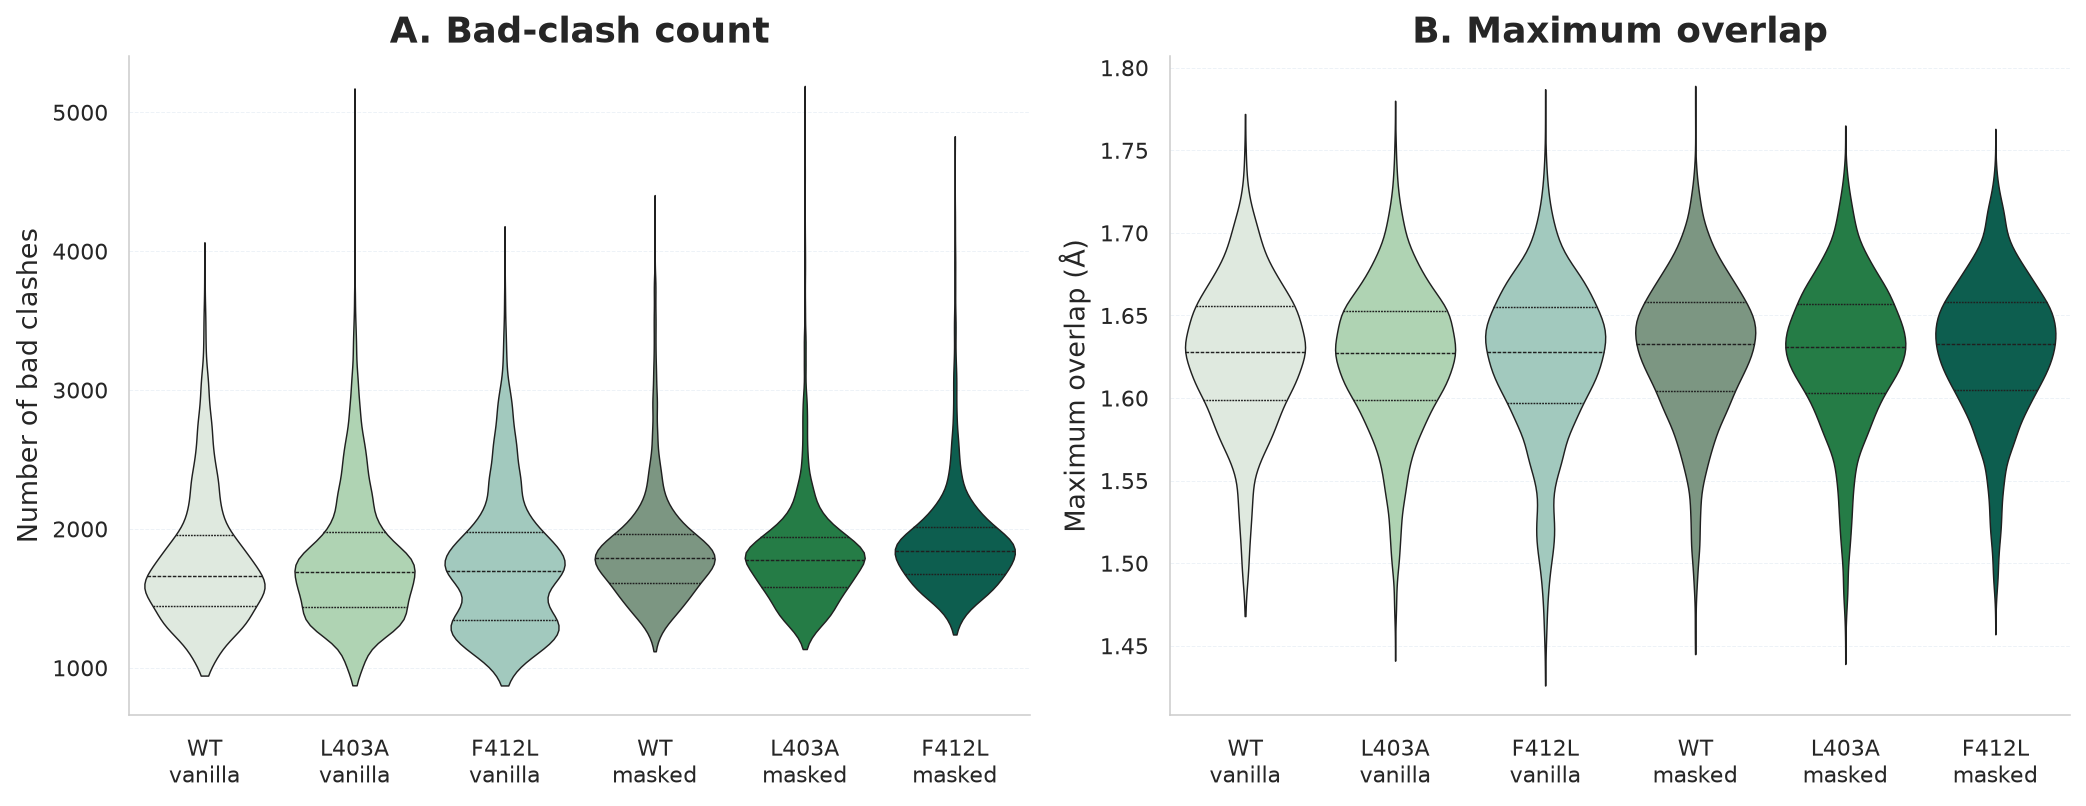

,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
55,repository_QC,F412L | masked,n_bad_clashes,3578,100,1839.000,1672.000,2013.000,341.000,1894.901,370.235,1240.000,4828.000
56,repository_QC,F412L | masked,max_overlap,3578,100,1.633,1.605,1.658,0.053,1.629,0.043,1.457,1.763
58,repository_QC,F412L | vanilla,n_bad_clashes,4407,100,1700.000,1347.000,1977.500,630.500,1746.942,493.935,873.000,4180.000
59,repository_QC,F412L | vanilla,max_overlap,4407,100,1.628,1.597,1.655,0.058,1.622,0.049,1.426,1.787
61,repository_QC,L403A | masked,n_bad_clashes,3693,100,1774.000,1585.000,1940.000,355.000,1808.667,367.748,1135.000,5190.000
62,repository_QC,L403A | masked,max_overlap,3693,100,1.631,1.603,1.657,0.054,1.627,0.045,1.439,1.765
64,repository_QC,L403A | vanilla,n_bad_clashes,4371,100,1692.000,1435.500,1975.000,539.500,1771.900,471.477,874.000,5172.000
65,repository_QC,L403A | vanilla,max_overlap,4371,100,1.627,1.599,1.653,0.054,1.624,0.045,1.441,1.780
67,repository_QC,WT | masked,n_bad_clashes,3658,100,1791.000,1613.000,1965.000,352.000,1845.669,385.539,1119.000,4404.000
68,repository_QC,WT | masked,max_overlap,3658,100,1.633,1.604,1.658,0.054,1.629,0.044,1.445,1.789


,A,B,metric,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH
28,WT | vanilla,WT | masked,n_bad_clashes,129.000,80.8775,43.7499,118.8668,0.3278,0.0001
29,WT | vanilla,WT | masked,max_overlap,0.005,0.0032,0.0007,0.0057,0.2047,0.0199
31,L403A | vanilla,L403A | masked,n_bad_clashes,82.000,36.0858,-1.5531,71.7217,0.1342,0.0903
32,L403A | vanilla,L403A | masked,max_overlap,0.004,0.0036,0.0010,0.0061,0.2188,0.0154
34,F412L | vanilla,F412L | masked,n_bad_clashes,139.000,148.1701,117.8243,179.5826,0.6590,0.0000
35,F412L | vanilla,F412L | masked,max_overlap,0.005,0.0065,0.0042,0.0090,0.4158,0.0000
37,WT | vanilla,L403A | vanilla,n_bad_clashes,30.000,6.6189,-31.4968,44.9458,0.0346,0.7642
38,WT | vanilla,L403A | vanilla,max_overlap,-0.001,-0.0018,-0.0042,0.0004,-0.1170,0.2099
40,WT | vanilla,F412L | vanilla,n_bad_clashes,38.000,-19.1840,-54.2932,14.3277,-0.0644,0.3404
41,WT | vanilla,F412L | vanilla,max_overlap,0.000,-0.0032,-0.0058,-0.0009,-0.2044,0.0205


In [6]:
mp.plot_diagnostics(cohorts, CHANNEL, OUT)
plt.show()
display(summary[(summary.cohort=='repository_QC') & summary.metric.ne('clashscore')].round(3))
display(contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.ne('clashscore')][
    ['A','B','metric','median_difference','seed_mean_difference','CI_low','CI_high','seed_rank_biserial','q_BH']].round(4))


## Recycle, AF-model, seed, and rank sensitivity
The full snapshot trace includes final separately and all early-recycle tails. The final-only analysis does not substitute a last available snapshot for a missing final file. The adjusted regression controls AF-model and snapshot composition, with uncertainty clustered by seed; its observation-weighted estimand differs from the seed-balanced primary result.

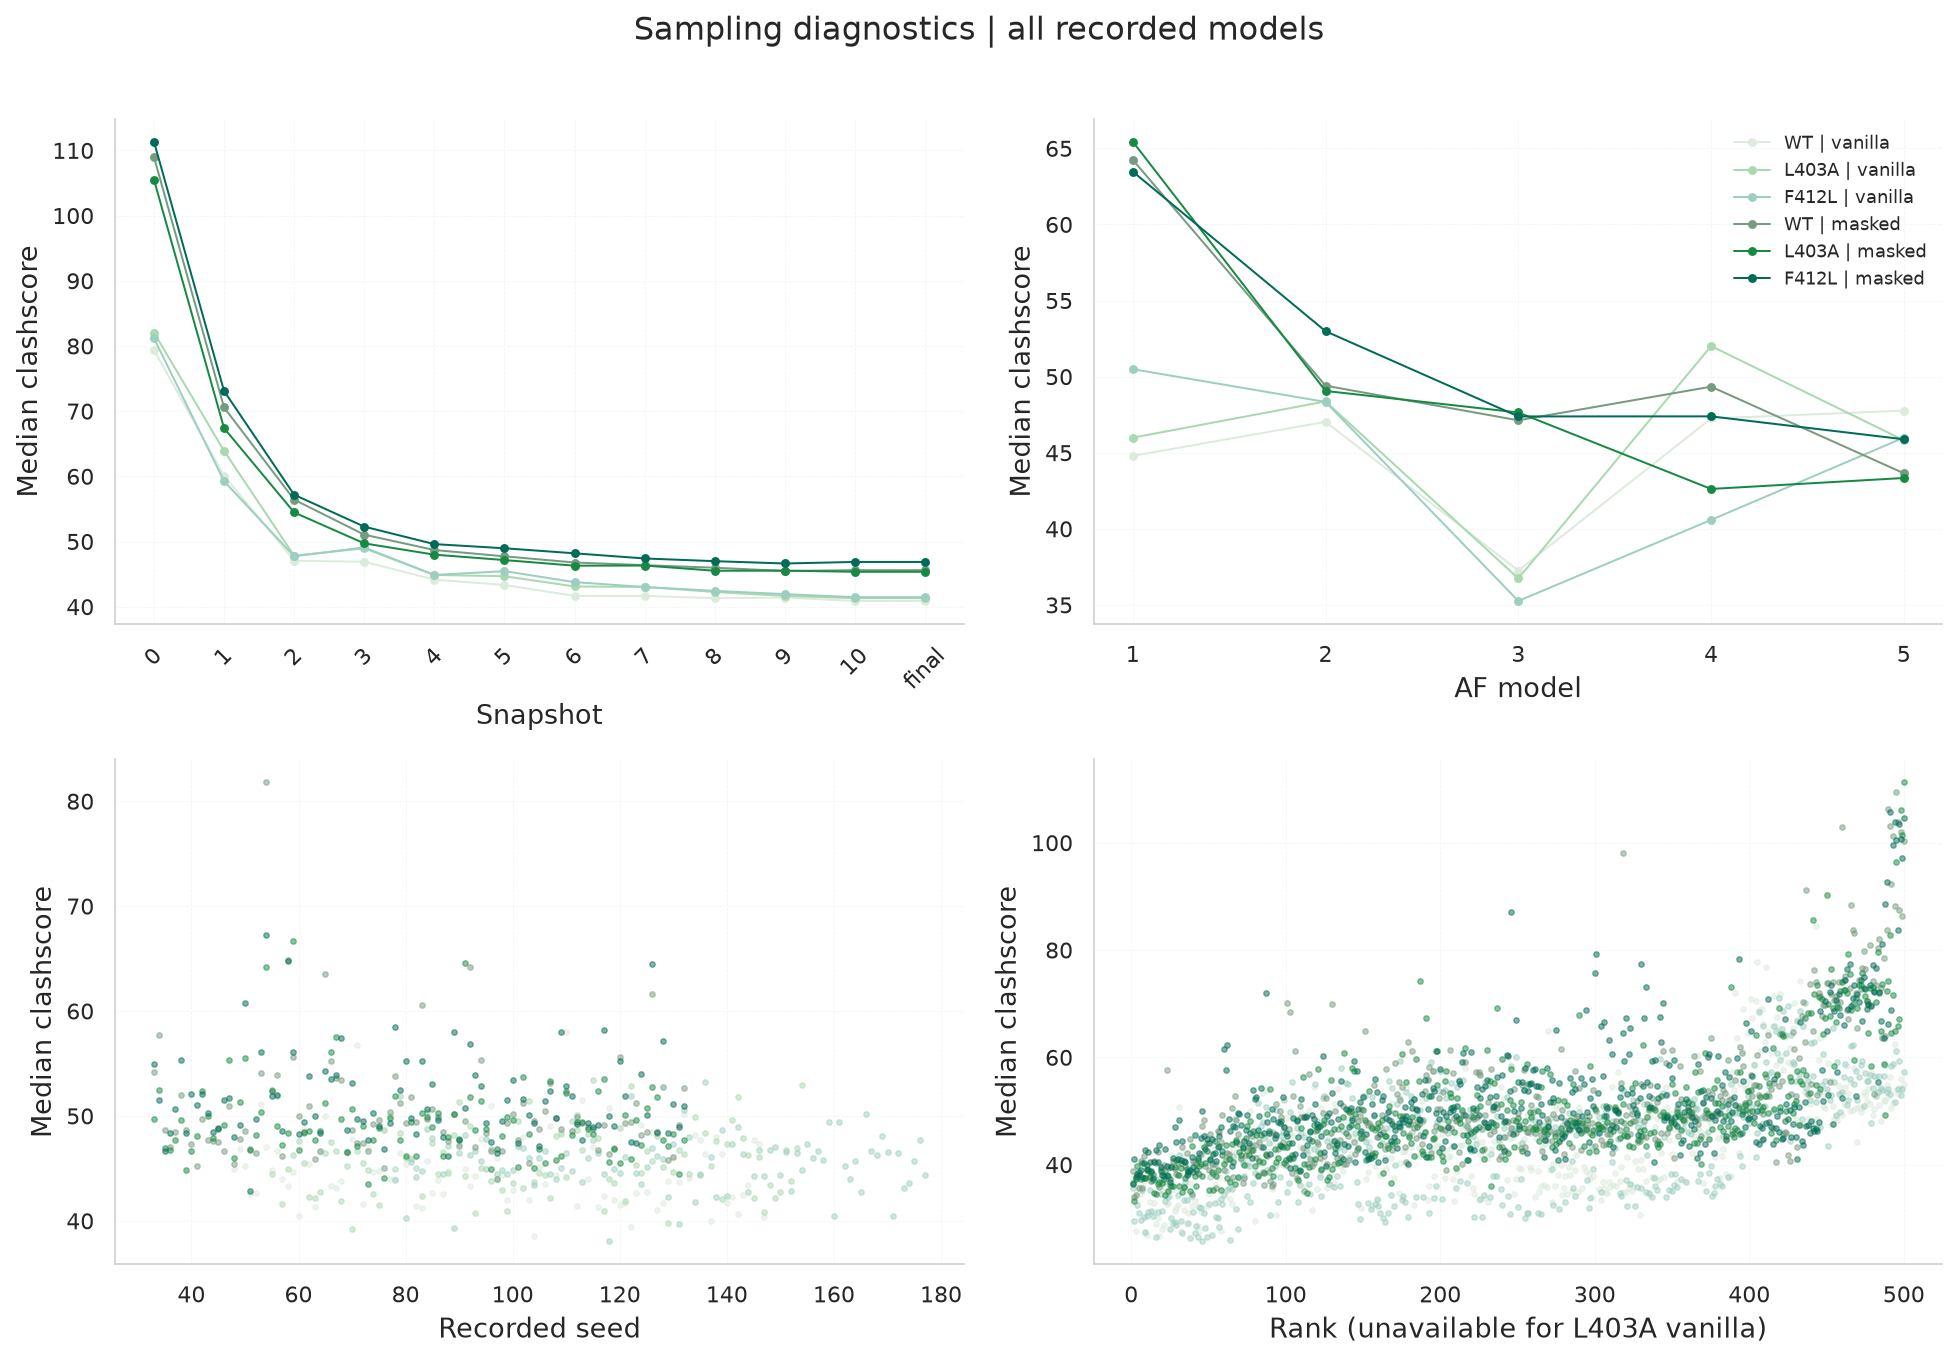

,A,B,adjusted_difference,CI_low,CI_high,p,q_BH
0,WT | vanilla,WT | masked,3.1685,2.2469,4.0901,0.0000,0.0000
1,L403A | vanilla,L403A | masked,1.7277,0.7262,2.7292,0.0007,0.0013
2,F412L | vanilla,F412L | masked,4.8075,4.0514,5.5636,0.0000,0.0000
3,WT | vanilla,L403A | vanilla,0.5393,-0.4156,1.4942,0.2683,0.2897
4,WT | vanilla,F412L | vanilla,-0.4830,-1.3770,0.4110,0.2897,0.2897
5,L403A | vanilla,F412L | vanilla,-0.9995,-1.8608,-0.1381,0.0230,0.0344
6,WT | masked,L403A | masked,-0.5912,-1.1259,-0.0566,0.0302,0.0388
7,WT | masked,F412L | masked,1.1123,0.5783,1.6463,0.0000,0.0001
8,L403A | masked,F412L | masked,1.6398,1.0992,2.1803,0.0000,0.0000


AF_model                                                1      2       3  \
A               B               mode                                       
F412L | vanilla F412L | masked  leave_AF_model_out  4.019  3.690   1.852   
                                only_AF_model       3.507  3.570  11.413   
L403A | masked  F412L | masked  leave_AF_model_out  2.401  1.641   2.826   
                                only_AF_model      -0.829  3.929   0.448   
L403A | vanilla F412L | vanilla leave_AF_model_out -1.768 -0.733  -0.562   
                                only_AF_model       4.287 -0.460  -0.990   
                L403A | masked  leave_AF_model_out -0.150  1.316  -1.537   
                                only_AF_model       8.623 -0.819   9.975   
WT | masked     F412L | masked  leave_AF_model_out  1.440  0.622   1.470   
                                only_AF_model      -0.948  3.560   0.879   
                L403A | masked  leave_AF_model_out -0.961 -1.019  -1.357   
                                only_AF_model      -0.119 -0.370   0.431   
WT | vanilla    F412L | vanilla leave_AF_model_out -1.647 -0.919   0.021   
                                only_AF_model       4.938  1.166  -2.247   
                L403A | vanilla leave_AF_model_out  0.121 -0.186   0.583   
                                only_AF_model       0.651  1.626  -1.257   
                WT | masked     leave_AF_model_out  0.932  2.148   0.403   
                                only_AF_model       9.393  1.176   8.288   

AF_model                                                4      5  
A               B               mode                              
F412L | vanilla F412L | masked  leave_AF_model_out  4.271  5.276  
                                only_AF_model      -0.151 -1.521  
L403A | masked  F412L | masked  leave_AF_model_out  1.903  2.237  
                                only_AF_model       1.817  2.034  
L403A | vanilla F412L | vanilla leave_AF_model_out  0.636 -1.115  
                                only_AF_model      -6.560  0.894  
                L403A | masked  leave_AF_model_out  3.004  1.924  
                                only_AF_model      -8.529 -2.661  
WT | masked     F412L | masked  leave_AF_model_out  1.692  1.023  
                                only_AF_model      -1.975  1.881  
                L403A | masked  leave_AF_model_out -0.210 -1.214  
                                only_AF_model      -3.792 -0.153  
WT | vanilla    F412L | vanilla leave_AF_model_out  0.529 -0.464  
                                only_AF_model      -4.777 -0.398  
                L403A | vanilla leave_AF_model_out -0.106  0.651  
                                only_AF_model       1.783 -1.292  
                WT | masked     leave_AF_model_out  3.108  3.789  
                                only_AF_model      -2.954 -3.800

,cohort,A,B,seed_mean_difference,CI_low,CI_high,q_BH
0,all_recycles,WT | vanilla,WT | masked,9.529,8.213,10.878,0.000
3,all_recycles,L403A | vanilla,L403A | masked,6.698,5.484,7.881,0.000
6,all_recycles,F412L | vanilla,F412L | masked,10.785,9.563,12.133,0.000
9,all_recycles,WT | vanilla,L403A | vanilla,1.129,0.171,2.113,0.031
12,all_recycles,WT | vanilla,F412L | vanilla,-0.172,-1.067,0.722,0.709
15,all_recycles,L403A | vanilla,F412L | vanilla,-1.302,-2.163,-0.399,0.008
18,all_recycles,WT | masked,L403A | masked,-1.702,-2.398,-1.017,0.000
21,all_recycles,WT | masked,F412L | masked,1.084,0.453,1.709,0.002
24,all_recycles,L403A | masked,F412L | masked,2.786,2.071,3.494,0.000
27,repository_QC,WT | vanilla,WT | masked,2.076,1.106,3.067,0.000


In [7]:
mp.stratification(cohorts, CHANNEL, OUT)
plt.show()
adjusted = mp.adjusted_contrasts(cohorts, CHANNEL, OUT)
display(adjusted.round(4))
af_sensitivity = mp.af_model_sensitivity(cohorts, CHANNEL, OUT)
display(af_sensitivity.pivot(index=['A','B','mode'], columns='AF_model', values='seed_mean_difference').round(3))
display(contrasts[contrasts.metric.eq('clashscore')][
    ['cohort','A','B','seed_mean_difference','CI_low','CI_high','q_BH']].round(3))


## S6 conformational association: join first, test second

The existing chain-resolved table contains all six ensembles. Join on **ensemble + exact PDB basename**,
require one record per canonical chain, and cross-check seed, AF model, and snapshot. No rank-based
matching or fuzzy filename normalization is permitted. The audit covers all recorded models; the
primary association uses the exact final structural-QC subset.

Two complementary existing-coordinate summaries are examined:

- Median canonical-chain F412-position Cα displacement from 8SD3 (Å), an **unsigned** magnitude.
  For F412L, the existing column refers to the homologous L412 Cα anchor.
- A directional projection of the four canonical-chain **whole-S6 rotations** onto the experimental
  8SD3→8SDA rotation vector: `dot(model − 8SD3, 8SDA − 8SD3) / norm(8SDA − 8SD3)^2`.
  Angular differences wrap to [−180°,180°). Zero is the WT rotation reference, one the mutant-reference
  projection. This is a derived summary of the existing coordinate, not a state classifier, a complete
  3-D conformation match, or a claim that projection one reproduces all four chains. Canonical subunit
  mapping is inherited from the validated analysis, not inferred from MolProbity.

Spearman correlation uses seed summaries (median per trajectory, equal AF-model mean within seed),
with 1,000 seed bootstrap draws. Descriptive model-level rho is also exported. Regressions adjust for
AF model/snapshot and cluster uncertainty by seed; slope × coordinate IQR expresses a local magnitude.
Direct interaction tests compare slopes between conditions rather than comparing significance labels.
The 12 association tests per method/cohort and the 18 interaction tests form separate BH families.
Raw-recycle, final-only, and r10 within the same structural-QC population are sensitivity analyses. Correlation cannot establish that
steric strain causes or limits S6 movement; early-recycle quality and survivor selection can influence it.


,ensemble,_merge,N
0,F412L | masked,both,6000
1,F412L | vanilla,both,6000
2,L403A | masked,both,6000
3,L403A | vanilla,both,5994
4,WT | masked,both,6000
5,WT | vanilla,both,6000


,canonical_subunit,8SD3,8SDA,experimental_delta
0,A,0.0,10.883062,10.883062
1,B,0.0,-38.513955,-38.513955
2,C,0.0,6.703495,6.703495
3,D,0.0,-42.517921,-42.517921


,cohort,ensemble,metric,N,missing_metric,seeds,model_spearman_rho,seed_spearman_rho,rho_CI_low,rho_CI_high,spearman_p,adjusted_slope,slope_CI_low,slope_CI_high,slope_p,metric_Q1,metric_Q3,fitted_clashscore_change_per_IQR,slope_q_BH,spearman_q_BH
0,repository_QC,F412L | masked,S6_shift_projection,3578,0,100,-0.1240,-0.0341,-0.2342,0.1594,0.7365,18.4297,13.1752,23.6841,0.0000,-0.0213,0.1651,3.4339,0.0000,0.7783
1,repository_QC,F412L | masked,F412_displacement_A,3578,0,100,-0.0385,0.1639,-0.0536,0.3612,0.1032,1.3625,1.0219,1.7031,0.0000,1.1721,3.1349,2.6743,0.0000,0.2064
2,repository_QC,F412L | vanilla,S6_shift_projection,4407,0,100,0.3270,0.0285,-0.1780,0.2303,0.7783,42.9451,17.4266,68.4637,0.0010,0.0691,0.1013,1.3835,0.0013,0.7783
3,repository_QC,F412L | vanilla,F412_displacement_A,4407,0,100,0.3957,-0.1378,-0.3534,0.0889,0.1715,3.7228,2.0362,5.4095,0.0000,0.9927,1.5403,2.0388,0.0000,0.2573
4,repository_QC,L403A | masked,S6_shift_projection,3693,0,100,-0.3553,-0.2612,-0.4172,-0.0823,0.0087,3.6262,-1.3490,8.6013,0.1531,-0.0068,0.0830,0.3255,0.1531,0.0346
5,repository_QC,L403A | masked,F412_displacement_A,3693,0,100,0.1269,0.1862,0.0000,0.3572,0.0636,1.0726,0.5437,1.6016,0.0001,0.8988,1.3681,0.5034,0.0001,0.1526
6,repository_QC,L403A | vanilla,S6_shift_projection,4371,0,100,0.3284,0.1163,-0.0863,0.2913,0.2492,51.5692,33.5258,69.6126,0.0000,0.0401,0.0612,1.0889,0.0000,0.2990
7,repository_QC,L403A | vanilla,F412_displacement_A,4371,0,100,0.6281,0.3109,0.1072,0.4822,0.0016,4.7169,3.0658,6.3679,0.0000,0.5768,0.7519,0.8260,0.0000,0.0099
8,repository_QC,WT | masked,S6_shift_projection,3658,0,100,-0.2282,-0.1199,-0.3227,0.0772,0.2346,5.9977,-0.2399,12.2352,0.0595,-0.0064,0.1124,0.7123,0.0649,0.2990
9,repository_QC,WT | masked,F412_displacement_A,3658,0,100,0.0709,0.1495,-0.0602,0.3450,0.1377,0.8196,0.3260,1.3131,0.0011,0.9763,1.7508,0.6347,0.0014,0.2360


,metric,A,B,slope_difference,CI_low,CI_high,p,q_BH
0,S6_shift_projection,WT | vanilla,WT | masked,-57.4711,-82.9392,-32.0029,0.0000,0.0001
1,S6_shift_projection,L403A | vanilla,L403A | masked,-47.9430,-66.9311,-28.9549,0.0000,0.0000
2,S6_shift_projection,F412L | vanilla,F412L | masked,-24.5155,-50.7409,1.7100,0.0669,0.1506
3,S6_shift_projection,WT | vanilla,L403A | vanilla,-11.8995,-44.3491,20.5500,0.4723,0.5313
4,S6_shift_projection,WT | vanilla,F412L | vanilla,-20.5236,-55.4689,14.4217,0.2497,0.4086
5,S6_shift_projection,L403A | vanilla,F412L | vanilla,-8.6240,-39.2806,22.0325,0.5814,0.5814
6,S6_shift_projection,WT | masked,L403A | masked,-2.3715,-9.7432,5.0002,0.5284,0.5594
7,S6_shift_projection,WT | masked,F412L | masked,12.4320,3.8886,20.9754,0.0043,0.0130
8,S6_shift_projection,L403A | masked,F412L | masked,14.8035,7.1970,22.4100,0.0001,0.0005
9,F412_displacement_A,WT | vanilla,WT | masked,-5.3422,-7.9471,-2.7373,0.0001,0.0003


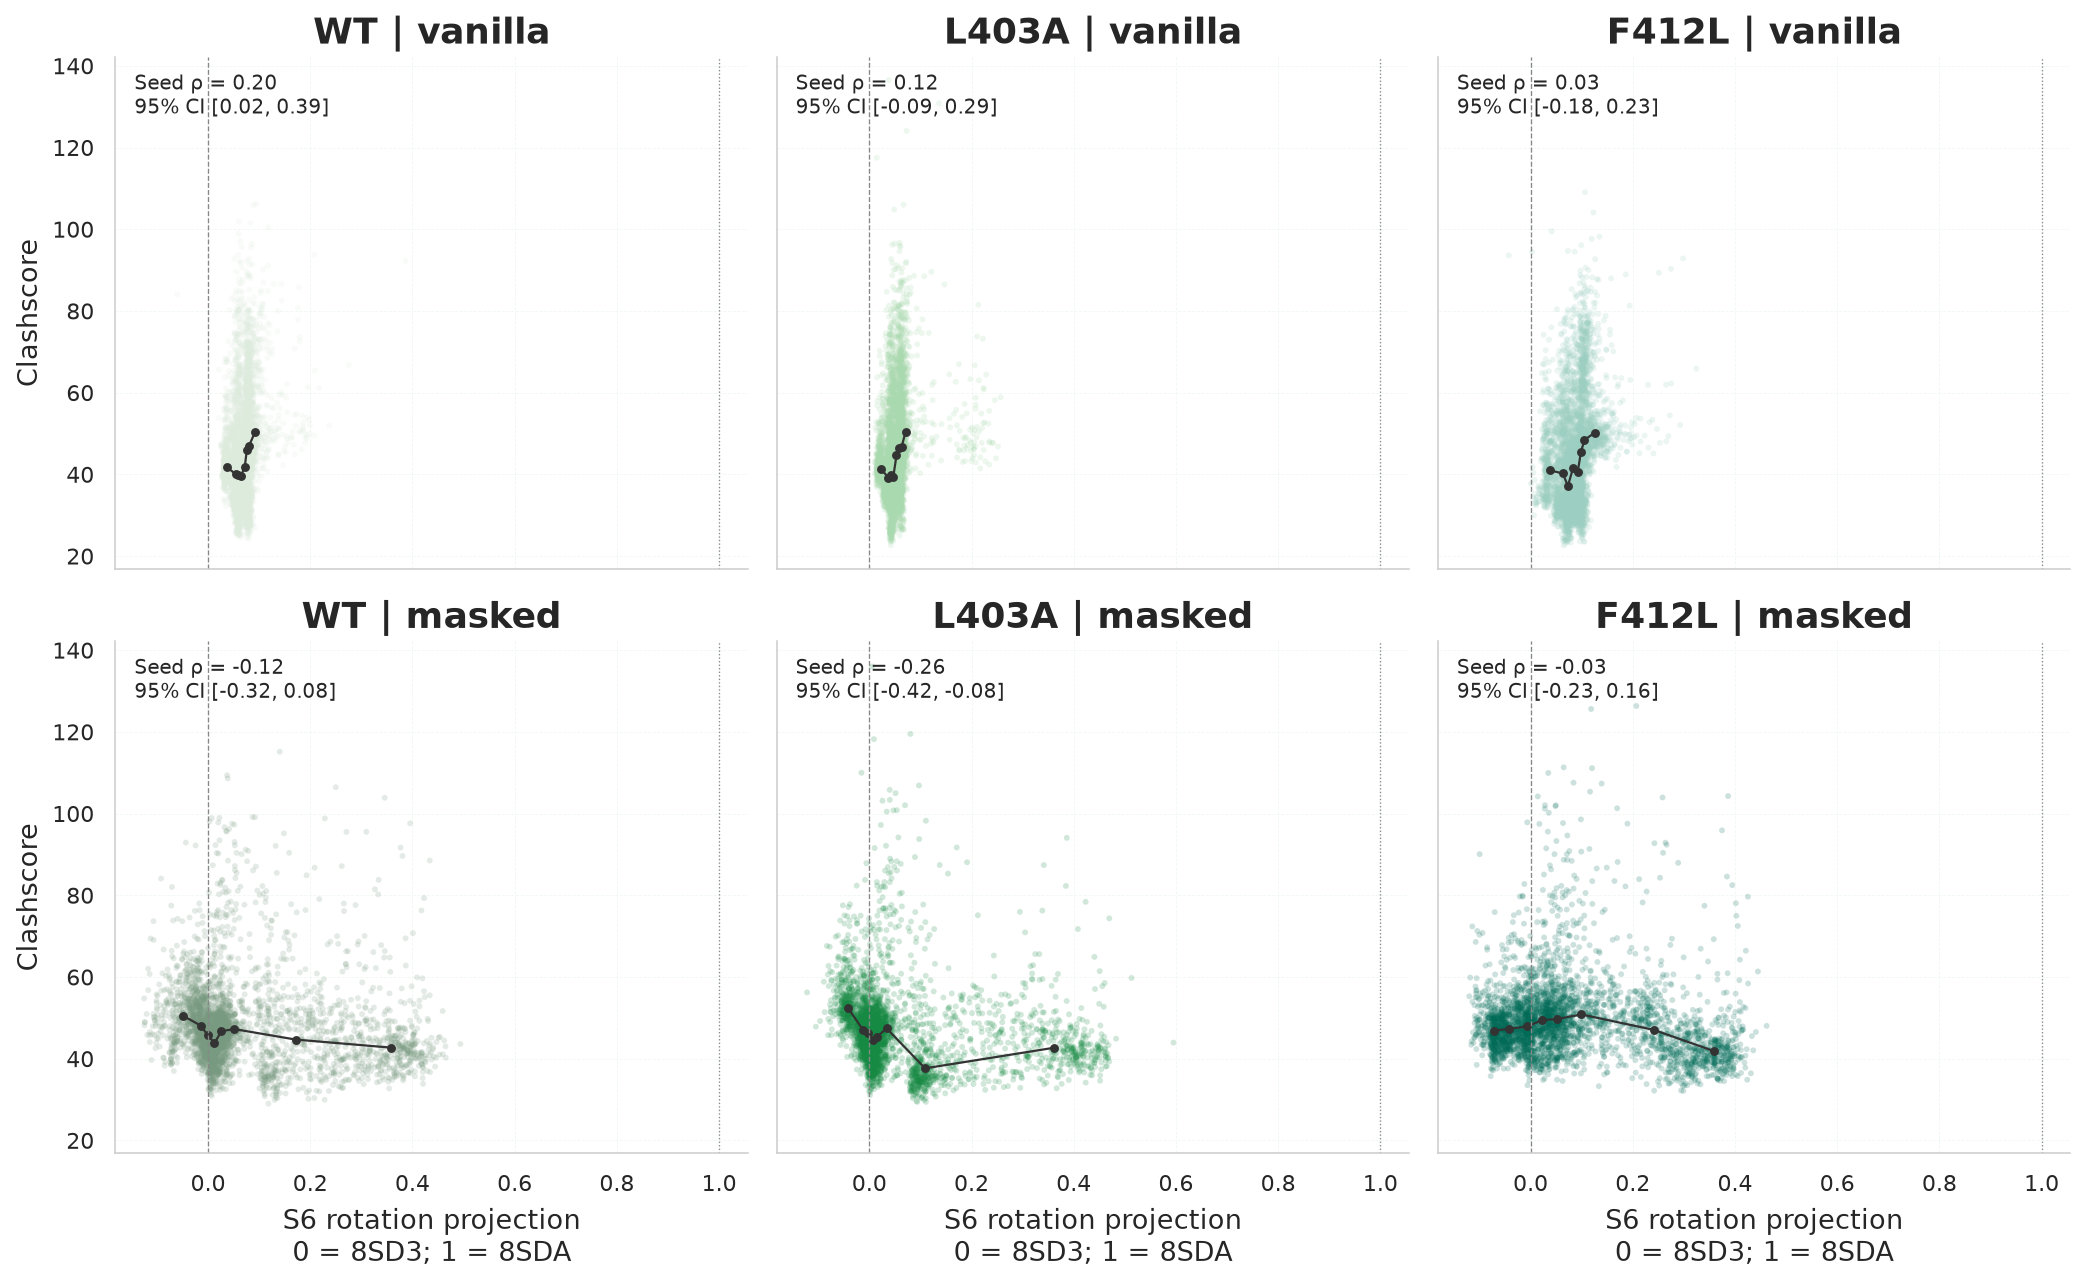

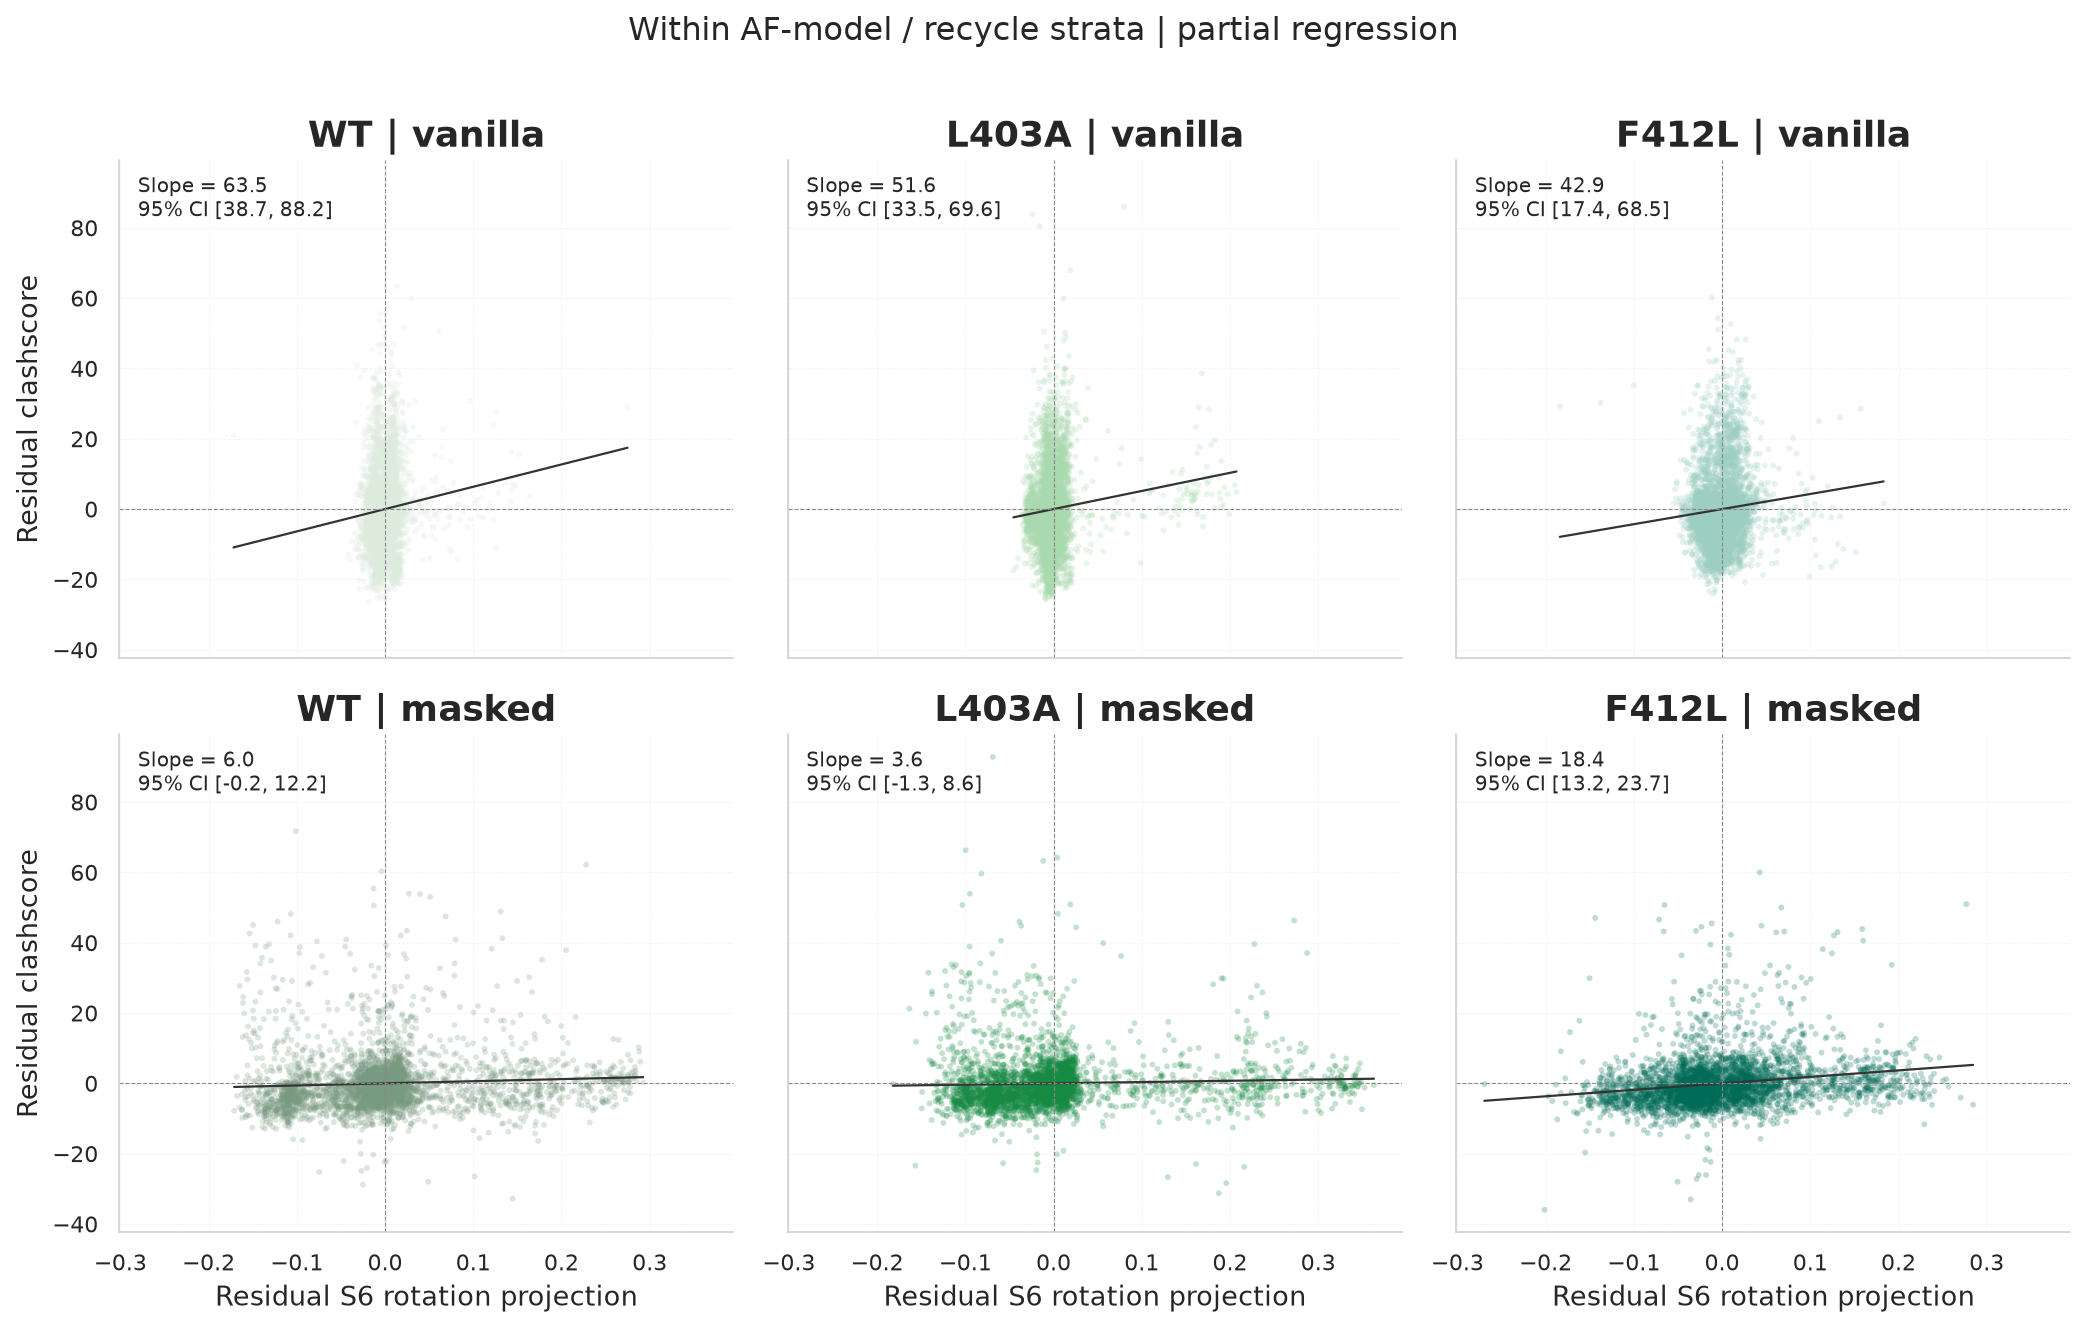

,cohort,ensemble,metric,N,missing_metric,seeds,model_spearman_rho,seed_spearman_rho,rho_CI_low,rho_CI_high,spearman_p,adjusted_slope,slope_CI_low,slope_CI_high,slope_p,metric_Q1,metric_Q3,fitted_clashscore_change_per_IQR,slope_q_BH,spearman_q_BH
12,r10_repository_QC,F412L | masked,S6_shift_projection,412,0,100,-0.3397,-0.0752,-0.2886,0.1246,0.4573,13.4512,8.6038,18.2986,0.0000,-0.0550,0.2375,3.9348,0.0000,0.4573
13,r10_repository_QC,F412L | masked,F412_displacement_A,412,0,100,-0.2212,0.0914,-0.1259,0.3011,0.3657,1.0204,0.6328,1.4080,0.0000,1.1126,2.1147,1.0225,0.0000,0.4298
14,r10_repository_QC,F412L | vanilla,S6_shift_projection,473,0,100,0.0750,-0.0995,-0.3048,0.1053,0.3248,43.0194,5.4984,80.5405,0.0246,0.0601,0.0934,1.4305,0.0386,0.4298
15,r10_repository_QC,F412L | vanilla,F412_displacement_A,473,0,100,0.3477,-0.2501,-0.4511,-0.0479,0.0121,-4.3851,-8.4795,-0.2907,0.0358,0.9707,1.5592,-2.5805,0.0430,0.0362
16,r10_repository_QC,L403A | masked,S6_shift_projection,426,0,100,-0.5667,-0.1782,-0.3629,0.0100,0.0761,4.9066,0.5938,9.2195,0.0258,-0.0017,0.0440,0.2243,0.0386,0.1827
17,r10_repository_QC,L403A | masked,F412_displacement_A,426,0,100,-0.0524,0.3029,0.1229,0.4593,0.0022,0.9901,0.5185,1.4616,0.0000,0.8432,1.0283,0.1832,0.0002,0.0104
18,r10_repository_QC,L403A | vanilla,S6_shift_projection,478,0,100,0.1763,0.0892,-0.1053,0.2812,0.3776,29.6042,9.0575,50.1508,0.0047,0.0371,0.0589,0.6440,0.0095,0.4298
19,r10_repository_QC,L403A | vanilla,F412_displacement_A,478,0,100,0.5979,0.3026,0.1059,0.4760,0.0022,3.7798,0.2909,7.2686,0.0337,0.5550,0.6930,0.5217,0.0430,0.0104
20,r10_repository_QC,WT | masked,S6_shift_projection,419,0,100,-0.4523,-0.0862,-0.2911,0.1131,0.3940,9.8152,4.1474,15.4830,0.0007,-0.0005,0.0628,0.6212,0.0017,0.4298
21,r10_repository_QC,WT | masked,F412_displacement_A,419,0,100,-0.1918,0.1254,-0.0811,0.3098,0.2139,0.8859,0.4172,1.3546,0.0002,0.9207,1.2436,0.2860,0.0006,0.4279


In [8]:
joined, associations, interactions = mp.kv21_conformation(cohorts, OUT)
display(pd.read_csv(OUT/'tables/conformation_join_audit.csv'))
display(pd.read_csv(OUT/'tables/S6_rotation_reference.csv'))
display(associations[associations.cohort.eq('repository_QC')].round(4))
display(interactions.round(4))
mp.plot_conformation(joined, associations, OUT)
plt.show()
mp.plot_conformation_adjusted(joined, associations, OUT)
plt.show()
display(associations[associations.cohort.eq('r10_repository_QC')].round(4))


## Focused interpretation
The following text is generated from the executed result tables so it stays synchronized with reruns.

In [9]:
display(Markdown(mp.focused_interpretation(summary, contrasts, CHANNEL, OUT)))

**Global quality and S6.** Masking changes the seed-balanced mean clashscore by WT: +2.076 (95% CI +1.106 to +3.067); L403A: +0.911 (95% CI -0.071 to +1.842); F412L: +3.821 (95% CI +3.031 to +4.640).

The original conformational table joins 35,994 available models exactly, including seed/AF-model/snapshot checks; 24,269 enter established structural QC. These are successful identity matches, not proof of coordinate checksums across cluster runs.

Directional S6 projection associations depend on aggregation and selection. For each ensemble below, compare the seed-level rank association with the AF-model/recycle-adjusted model-level slope; they estimate different relationships:

- F412L | masked: seed ρ=-0.03 (95% CI -0.23 to +0.16); adjusted slope +18.43 clashscore per projection unit, CI [13.18, 23.68], equivalent to +3.43 over that ensemble’s coordinate IQR.

- F412L | vanilla: seed ρ=+0.03 (95% CI -0.18 to +0.23); adjusted slope +42.95 clashscore per projection unit, CI [17.43, 68.46], equivalent to +1.38 over that ensemble’s coordinate IQR.

- L403A | masked: seed ρ=-0.26 (95% CI -0.42 to -0.08); adjusted slope +3.63 clashscore per projection unit, CI [-1.35, 8.60], equivalent to +0.33 over that ensemble’s coordinate IQR.

- L403A | vanilla: seed ρ=+0.12 (95% CI -0.09 to +0.29); adjusted slope +51.57 clashscore per projection unit, CI [33.53, 69.61], equivalent to +1.09 over that ensemble’s coordinate IQR.

- WT | masked: seed ρ=-0.12 (95% CI -0.32 to +0.08); adjusted slope +6.00 clashscore per projection unit, CI [-0.24, 12.24], equivalent to +0.71 over that ensemble’s coordinate IQR.

- WT | vanilla: seed ρ=+0.20 (95% CI +0.02 to +0.39); adjusted slope +63.47 clashscore per projection unit, CI [38.70, 88.24], equivalent to +1.36 over that ensemble’s coordinate IQR.

**r10 within the same QC population:**

- F412L | masked: seed ρ=-0.08 (95% CI -0.29 to +0.12); adjusted slope +13.45, CI [8.60, 18.30].

- F412L | vanilla: seed ρ=-0.10 (95% CI -0.30 to +0.11); adjusted slope +43.02, CI [5.50, 80.54].

- L403A | masked: seed ρ=-0.18 (95% CI -0.36 to +0.01); adjusted slope +4.91, CI [0.59, 9.22].

- L403A | vanilla: seed ρ=+0.09 (95% CI -0.11 to +0.28); adjusted slope +29.60, CI [9.06, 50.15].

- WT | masked: seed ρ=-0.09 (95% CI -0.29 to +0.11); adjusted slope +9.82, CI [4.15, 15.48].

- WT | vanilla: seed ρ=+0.10 (95% CI -0.11 to +0.31); adjusted slope +53.90, CI [-10.02, 117.83].

Unsigned F412-position displacement has positive adjusted slopes in the pooled QC analysis, but this is not universal across the r10 sensitivities and does not establish motion toward 8SDA. A universal steric ceiling on the experimentally directed S6 shift is not established: marginal and conditional associations differ, early-recycle behavior matters, and the analysis observes sampled survivors rather than an energetic barrier. The S6 association is exploratory and potentially figure-worthy only with the selection/adjustment sensitivity shown. Atom-level S6/interface clash localization followed by controlled relaxation of matched models would be more informative about a steric mechanism; correlation alone is not causation.

**AF-model dependence.** The following ranges are effect magnitudes, not new hypothesis tests:

- WT masked−vanilla: individual AF-model mean differences range from -3.80 to +9.39; leaving out one AF model at a time gives +0.40 to +3.79.

- L403A masked−vanilla: individual AF-model mean differences range from -8.53 to +9.98; leaving out one AF model at a time gives -1.54 to +3.00.

- F412L masked−vanilla: individual AF-model mean differences range from -1.52 to +11.41; leaving out one AF model at a time gives +1.85 to +5.28.

Mixed signs across AF models preclude a uniform per-model masking effect. The stratified tables and final-r10 sensitivities should accompany claims based on pooled means.

## Reproducibility record
All generated outputs are confined to this channel’s `dataExtra/molprobity/{tables,figures}`. Existing figures and analyses are not overwritten. Input hashes, missing-model lists, full descriptive/contrast tables, pairing diagnostics and sensitivity results accompany the figures.

In [10]:
record = {'channel': CHANNEL, 'total_downloaded_csvs': total_csv_files,
          'channel_csvs': len(inventory), 'rows': len(raw), 'python': platform.python_version(),
          'bootstrap_replicates': mp.BOOTSTRAPS, 'random_seed': mp.RANDOM_SEED,
          'packages': {p: importlib.metadata.version(p) for p in ['numpy','pandas','scipy','statsmodels','matplotlib','seaborn']}}
(OUT/'tables/run_metadata.json').write_text(json.dumps(record, indent=2)+chr(10))
print('Completed:', OUT.relative_to(ROOT))


Completed: kv21/dataExtra/molprobity
